In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Functions

In [2]:
# compute metrics by group
def compute_metrics_by_group(df_data, str_group_col, str_pred_col, str_target):
    list_rows = []
    for str_group, df_group in df_data.groupby(str_group_col):
        arr_y_true = df_group[str_target].values
        arr_y_pred = df_group[str_pred_col].values
        dict_row = {
            'str_group': str_group,
            'int_n': len(df_group),
            'flt_target_mean': arr_y_true.mean(),
            'flt_pred_mean': arr_y_pred.mean(),
            'flt_pred_median': np.median(arr_y_pred),
            'flt_auc': roc_auc_score(arr_y_true, arr_y_pred),
        }
        list_rows.append(dict_row)
    return pd.DataFrame(list_rows)

In [3]:
# plot kde of predictions by group
def plot_kde_by_group(df_data, str_group_col, str_pred_col, str_filename='output/kde_by_group.png'):
    warnings.filterwarnings('ignore')
    fig, ax = plt.subplots(figsize=(10, 5))
    list_colors = ['steelblue', 'salmon']
    for (str_group, df_group), str_color in zip(df_data.groupby(str_group_col), list_colors):
        flt_median = np.median(df_group[str_pred_col].values)
        sns.kdeplot(df_group[str_pred_col], ax=ax, color=str_color, linewidth=2, label=f'{str_group} (Median={flt_median:.4f})', fill=True, alpha=0.2)
    ax.set_title(f'KDE of Predictions by {str_group_col}', fontsize=16)
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

In [4]:
# plot metric comparison by group
def plot_metric_comparison(df_metrics, str_metric, str_title, str_filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(df_metrics['str_group'].astype(str), df_metrics[str_metric], color='steelblue', edgecolor='black')
    ax.set_title(str_title, fontsize=16)
    ax.set_xlabel('Age Group', fontsize=12)
    ax.set_ylabel(str_metric, fontsize=12)
    # annotate bars
    for i, flt_val in enumerate(df_metrics[str_metric]):
        ax.text(i, flt_val + (ax.get_ylim()[1] * 0.01), f'{flt_val:.4f}', ha='center', fontsize=11)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [5]:
# plot age vs credit risk shap importance comparison
def plot_age_vs_credit_importance(model_age, model_credit, arr_X_age, arr_X_credit, list_cols, str_filename='output/age_vs_credit_importance.png'):
    # shap for age model
    explainer_age = shap.TreeExplainer(model_age)
    shap_values_age = explainer_age.shap_values(arr_X_age)
    arr_shap_age = np.abs(shap_values_age).mean(axis=0)
    arr_shap_age_norm = arr_shap_age / arr_shap_age.max() if arr_shap_age.max() > 0 else arr_shap_age
    # shap for credit risk model
    explainer_credit = shap.TreeExplainer(model_credit)
    shap_values_credit = explainer_credit.shap_values(arr_X_credit)
    arr_shap_credit = np.abs(shap_values_credit).mean(axis=0)
    arr_shap_credit_norm = arr_shap_credit / arr_shap_credit.max() if arr_shap_credit.max() > 0 else arr_shap_credit
    # build dataframe and sort by age shap
    df_importance = pd.DataFrame({
        'str_feature': list_cols,
        'flt_shap_age': arr_shap_age_norm,
        'flt_shap_credit': arr_shap_credit_norm,
    }).sort_values('flt_shap_age', ascending=True)
    # plot
    arr_y = np.arange(len(list_cols))
    flt_bar_height = 0.35
    fig, ax = plt.subplots(figsize=(10, max(5, len(list_cols) * 0.5)))
    ax.barh(arr_y + flt_bar_height / 2, df_importance['flt_shap_age'].values, flt_bar_height, label='Age Prediction', color='salmon', edgecolor='black')
    ax.barh(arr_y - flt_bar_height / 2, df_importance['flt_shap_credit'].values, flt_bar_height, label='Default Prediction', color='steelblue', edgecolor='black')
    ax.set_yticks(arr_y)
    ax.set_yticklabels(df_importance['str_feature'].values)
    ax.set_title('SHAP Importance: Age Prediction vs Default Prediction', fontsize=16)
    ax.set_xlabel('Normalized SHAP Importance', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [6]:
# plot shap partial dependence plots for age proxy model
def plot_age_shap_pdp(model_age, arr_X, list_cols, str_filename='output/age_shap_pdp.png'):
    explainer = shap.TreeExplainer(model_age)
    shap_values = explainer.shap_values(arr_X)
    int_n_features = len(list_cols)
    int_n_cols = 3
    int_n_rows = int(np.ceil(int_n_features / int_n_cols))
    fig, axes = plt.subplots(int_n_rows, int_n_cols, figsize=(6 * int_n_cols, 4 * int_n_rows))
    axes = axes.flatten()
    for i, str_col in enumerate(list_cols):
        ax = axes[i]
        ax.scatter(arr_X[:, i], shap_values[:, i], alpha=0.3, s=5, color='salmon')
        ax.set_title(str_col, fontsize=12)
        ax.set_xlabel('Feature Value', fontsize=10)
        ax.set_ylabel('SHAP Value', fontsize=10)
        ax.axhline(y=0, color='black', linewidth=0.5)
    # hide unused axes
    for j in range(int_n_features, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('SHAP Partial Dependence Plots (Age Proxy Model)', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300, bbox_inches='tight')
    plt.show()

#### Constants

In [7]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 input path
str_s3_input = f's3://{str_bucket}/03_preprocessing'
print(f'S3 Input: {str_s3_input}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# model and feature columns
str_model_path = '../04_model/output/xgboost_model.joblib'
str_feature_cols_path = '../04_model/output/feature_cols.joblib'

# protected class column and threshold
str_age_col = 'int_age'
int_age_threshold = 60
print(f'Age threshold: {int_age_threshold}')

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 06_disparate_impact
S3 Input: s3://credit-risk-claude/03_preprocessing
Target: default_12m
Age threshold: 60


#### Read Data and Model

In [8]:
# read test data only
df_test = pd.read_parquet(f'{str_s3_input}/df_test_clean.parquet')

# load model and feature columns
model = joblib.load(str_model_path)
list_feature_cols = joblib.load(str_feature_cols_path)

print(f'Test: {df_test.shape}')
print(f'Features: {len(list_feature_cols)}')

Test: (3797, 20)
Features: 12


#### Define Age Groups

Under ECOA (Equal Credit Opportunity Act), age is a protected class. Although `int_age` was excluded from model features for compliance, we must verify the model does not produce disparate outcomes across age groups. Applicants are segmented into under 60 and 60+ for this analysis.

In [9]:
# generate predictions
df_test['flt_pred'] = model.predict_proba(df_test[list_feature_cols].values)[:, 1]

# create age group
df_test['str_age_group'] = np.where(df_test[str_age_col] >= int_age_threshold, f'>={int_age_threshold}', f'<{int_age_threshold}')

# print group counts
print(df_test['str_age_group'].value_counts())

str_age_group
<60     3690
>=60     107
Name: count, dtype: int64


#### Metrics by Age Group

Compare sample size, actual default rate, mean/median predicted probability, and AUC between age groups. Large differences in predicted probabilities or AUC may indicate disparate impact.

In [10]:
df_di_metrics = compute_metrics_by_group(df_test, 'str_age_group', 'flt_pred', str_target)
df_di_metrics.to_csv('output/disparate_impact_metrics.csv', index=False)
df_di_metrics

,str_group,int_n,flt_target_mean,flt_pred_mean,flt_pred_median,flt_auc
0,<60,3690,0.183198,0.188103,0.129248,0.803097
1,>=60,107,0.158879,0.184519,0.129285,0.733987


#### Mean Predicted Probability by Age Group

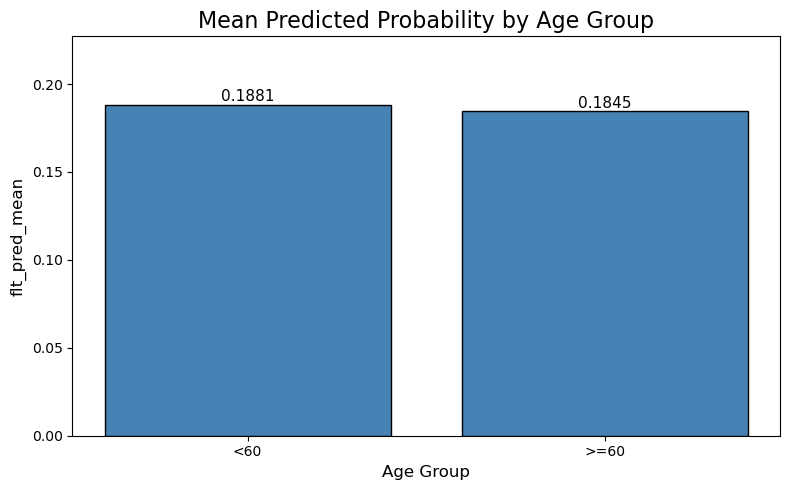

In [11]:
plot_metric_comparison(df_di_metrics, 'flt_pred_mean', 'Mean Predicted Probability by Age Group', 'output/pred_mean_by_age.png')

#### Actual Default Rate by Age Group

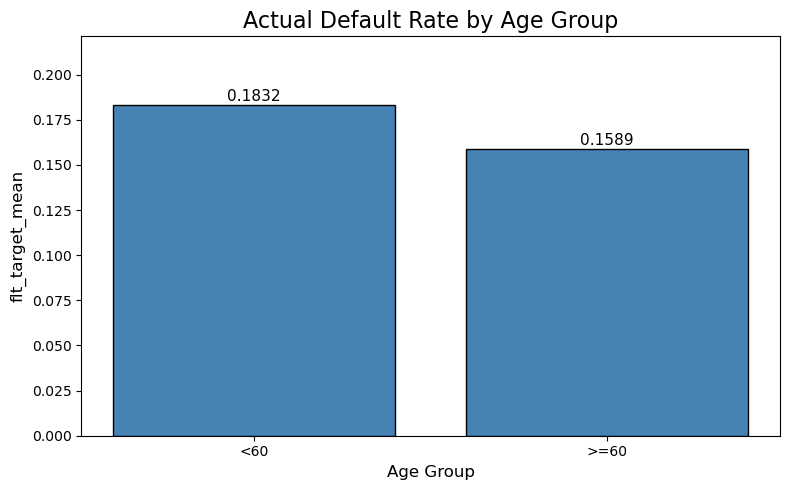

In [12]:
plot_metric_comparison(df_di_metrics, 'flt_target_mean', 'Actual Default Rate by Age Group', 'output/target_mean_by_age.png')

#### AUC by Age Group

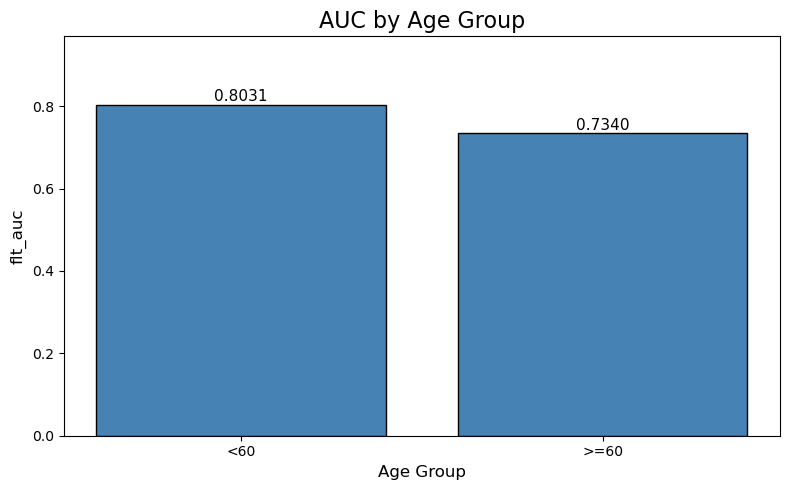

In [13]:
plot_metric_comparison(df_di_metrics, 'flt_auc', 'AUC by Age Group', 'output/auc_by_age.png')

#### KDE of Predictions by Age Group

Comparing the distribution of predicted probabilities between age groups. Similar distributions suggest the model treats both groups comparably. A significant shift would indicate the model may be producing disparate outcomes.

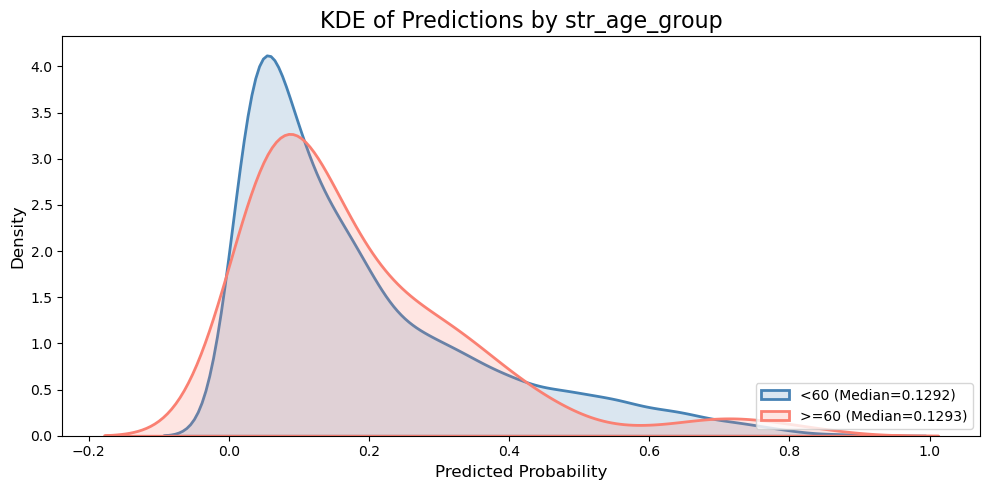

In [14]:
plot_kde_by_group(df_test, 'str_age_group', 'flt_pred')

#### KS Test

The Kolmogorov-Smirnov test formally tests whether the distributions of predictions between the two age groups are statistically different. A large KS statistic and small p-value would indicate significant distributional differences.

In [15]:
# ks test between age groups
arr_pred_young = df_test.loc[df_test['str_age_group'] == f'<{int_age_threshold}', 'flt_pred'].values
arr_pred_old = df_test.loc[df_test['str_age_group'] == f'>={int_age_threshold}', 'flt_pred'].values

ks_result = ks_2samp(arr_pred_young, arr_pred_old)
print(f'KS Statistic: {ks_result.statistic:.4f}')
print(f'P-Value: {ks_result.pvalue:.4f}')

KS Statistic: 0.0960
P-Value: 0.2750


#### Age Proxy Model

A quick XGBoost model is trained to predict the age group (< 60 vs >= 60) using the same features as the credit risk model. If any feature is highly predictive of age, it may be acting as a proxy for the protected class and should be flagged for review.

In [16]:
# create binary age target
arr_y_age = (df_test[str_age_col] >= int_age_threshold).astype(int).values
arr_X_age = df_test[list_feature_cols].values

# train quick xgboost model to predict age group
warnings.filterwarnings('ignore')
model_age = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    verbosity=0,
)
model_age.fit(arr_X_age, arr_y_age)

# auc for predicting age group
arr_y_age_pred = model_age.predict_proba(arr_X_age)[:, 1]
flt_age_auc = roc_auc_score(arr_y_age, arr_y_age_pred)
print(f'Age Proxy Model AUC: {flt_age_auc:.4f}')
warnings.filterwarnings('default')

Age Proxy Model AUC: 0.9782


#### Age Proxy vs Credit Risk Feature Importance

Comparing SHAP importance between the age proxy model and the credit risk model. Features that are important for both predicting age and predicting default are potential proxy concerns - the model may be indirectly using age-correlated information to make credit decisions.

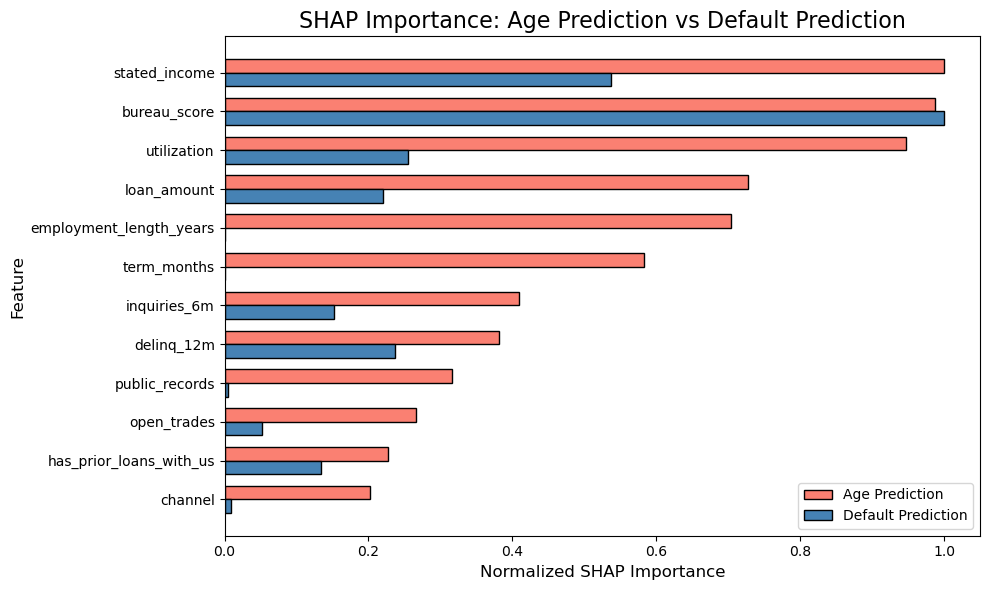

In [17]:
plot_age_vs_credit_importance(model_age, model, arr_X_age, df_test[list_feature_cols].values, list_feature_cols)

#### Age Proxy SHAP Partial Dependence Plots

SHAP partial dependence plots from the age proxy model show how each feature's value relates to predicting age group membership. These reveal the direction and shape of each feature's relationship with age, helping identify which features serve as the strongest proxies.

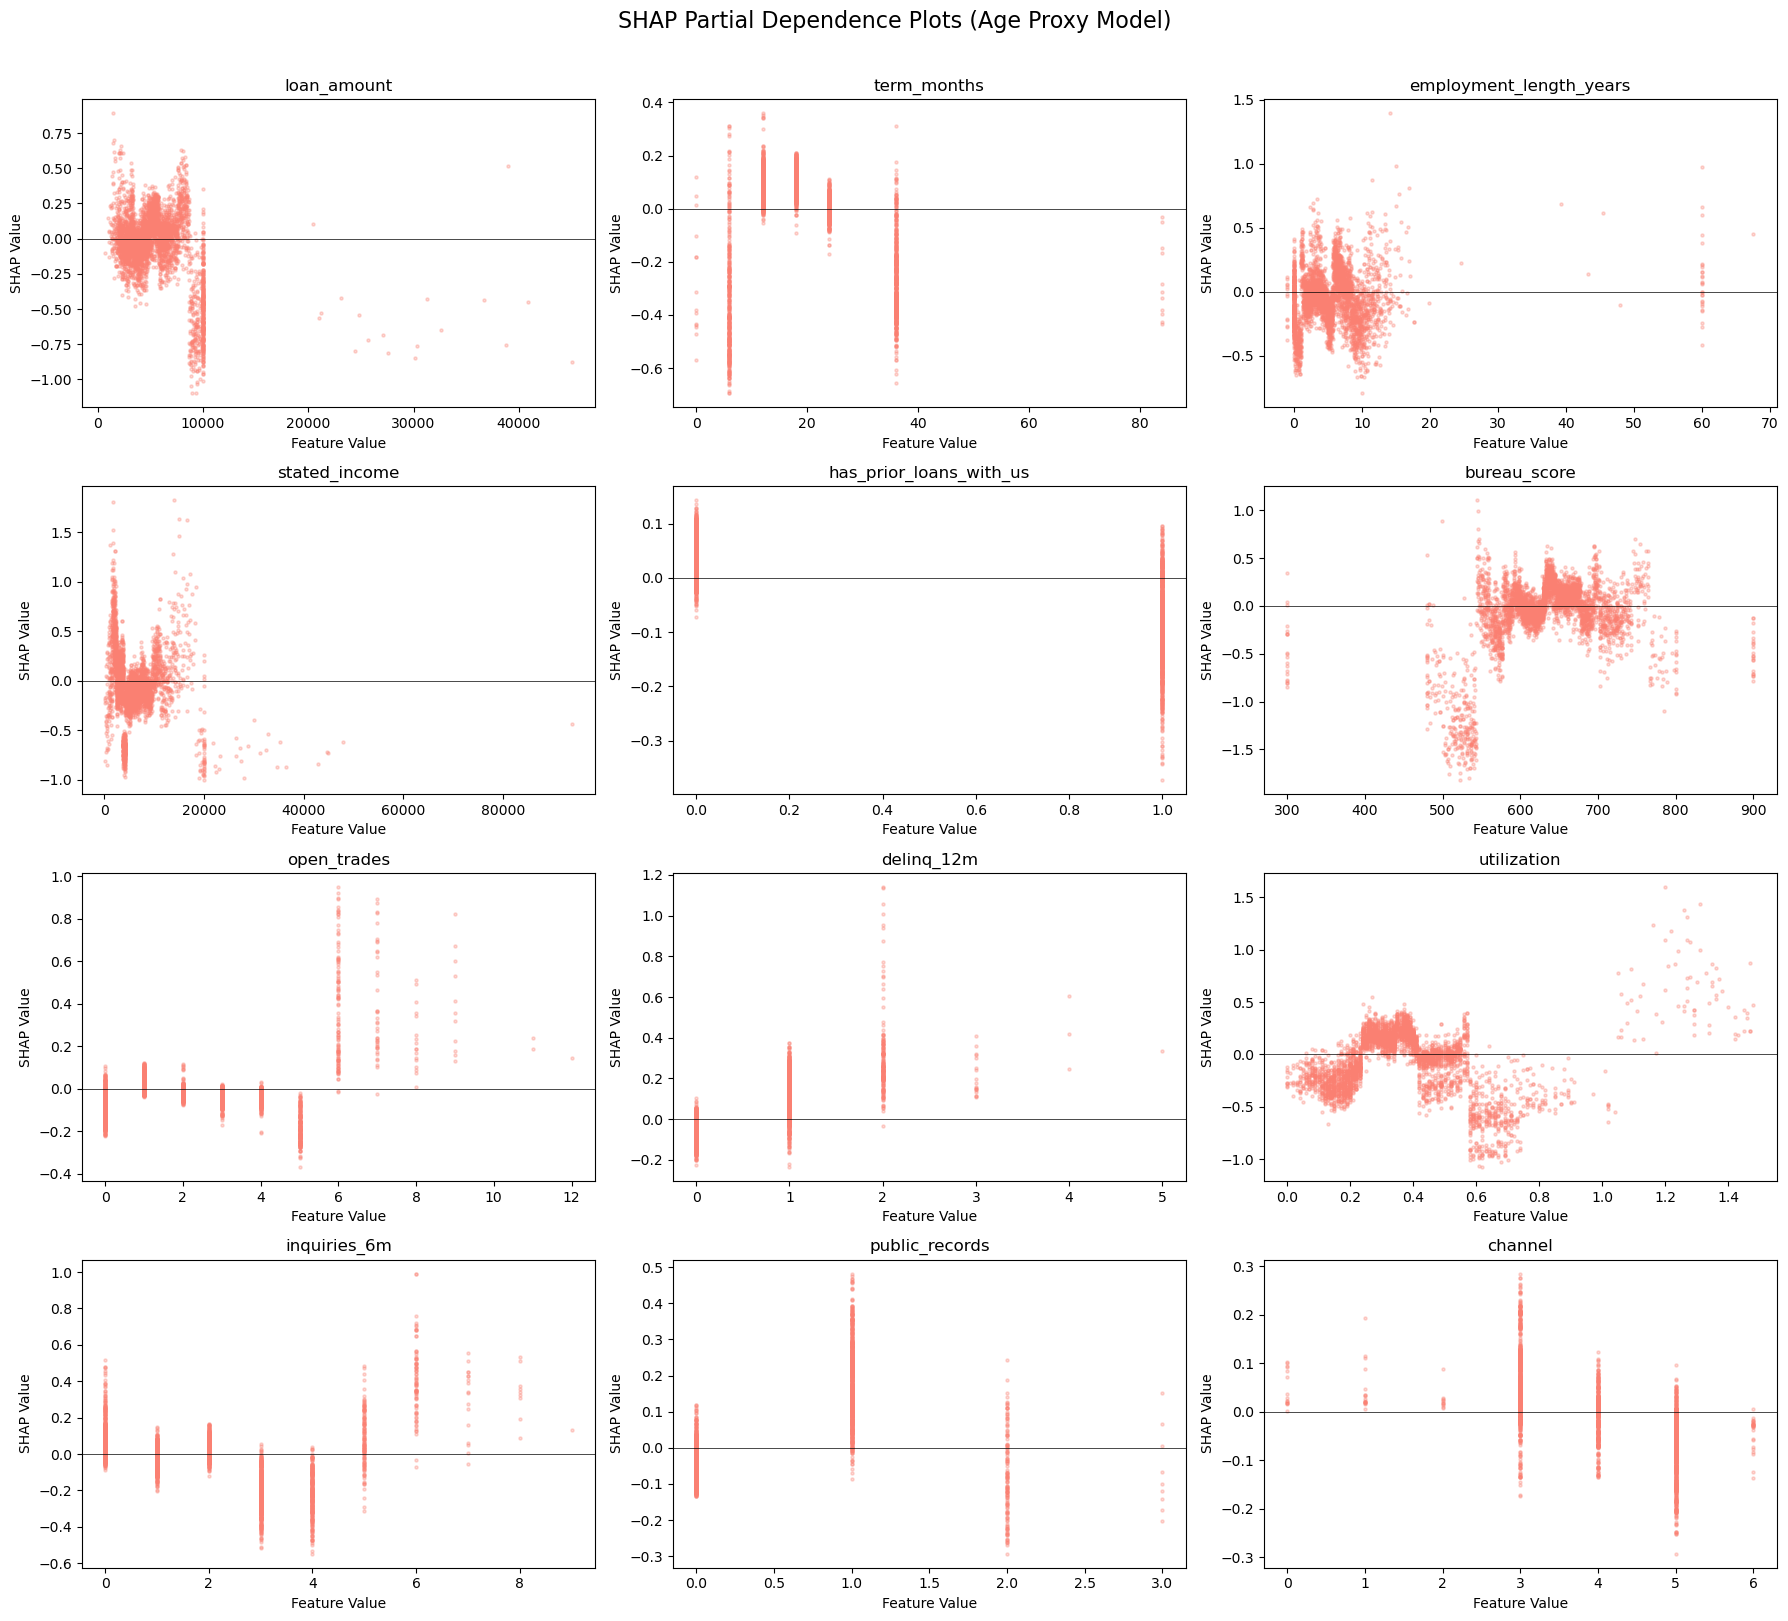

In [18]:
plot_age_shap_pdp(model_age, arr_X_age, list_feature_cols)